In [7]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [ ]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_rate=0.1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.bottleneck = conv_block(128, 256)
        self.drop = nn.Dropout2d(dropout_rate)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))
        b = self.drop(b)

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat((e2, d2), dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat((e1, d1), dim=1))

        return self.final(d1)

In [ ]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [ ]:
class Trainer:
    def __init__(self, config):
        self.config = config
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.model = UNet(dropout_rate=0.1).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()
        print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0
        for images, masks in tqdm(self.train_dataloader, desc="Training"):
            images, masks = images.to(self.config.device), masks.to(self.config.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []
        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, desc="Validating"):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()
                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)
                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []
        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, desc="Testing"):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()
                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)
                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()
        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)
                output = torch.sigmoid(self.model(img_tensor)).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')
                axes[i, 0].imshow(img.permute(1, 2, 0).cpu()); axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray"); axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray"); axes[i, 2].set_title("Predicted Mask")
            plt.show()


>>> Запуск эксперимента: LR_0.001_BS_8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
Validating: 100%|██████████| 92/92 [00:11<00:00,  7.89it/s]


Epoch 1 / 5, Train Loss: 0.4998, Val Loss: 0.4323, Val IoU: 0.7394, Val F1-score: 0.8418


Validating: 100%|██████████| 92/92 [00:11<00:00,  7.96it/s]


Epoch 2 / 5, Train Loss: 0.4043, Val Loss: 0.3929, Val IoU: 0.7529, Val F1-score: 0.8514


...

Epoch 4 / 5, Train Loss: 0.3724, Val Loss: 0.3539, Val IoU: 0.8056, Val F1-score: 0.8869


Validating: 100%|██████████| 23/23 [00:10<00:00,  2.24it/s]


Epoch 5 / 5, Train Loss: 0.3479, Val Loss: 0.3562, Val IoU: 0.7948, Val F1-score: 0.8795
Testing...


Testing: 100%|██████████| 115/115 [00:53<00:00,  2.13it/s]


Test Loss: 0.3540, Test IoU: 0.7904, Test F1-score: 0.8758


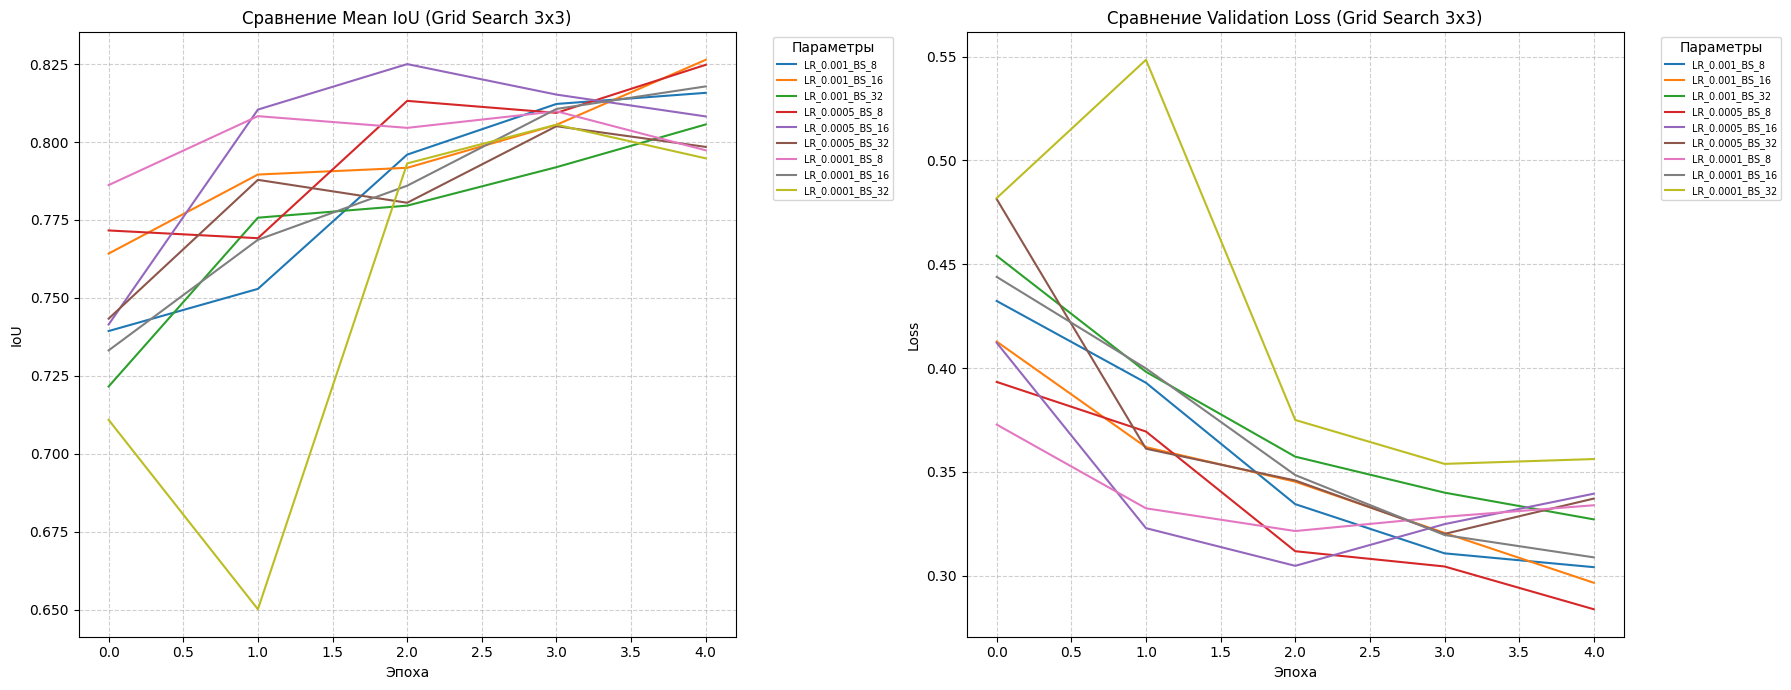


Итоговая сводка экспериментов
Эксперимент LR_0.001_BS_8: Max IoU = 0.8158
Эксперимент LR_0.001_BS_16: Max IoU = 0.8264
Эксперимент LR_0.001_BS_32: Max IoU = 0.8057
Эксперимент LR_0.0005_BS_8: Max IoU = 0.8248
Эксперимент LR_0.0005_BS_16: Max IoU = 0.8250
Эксперимент LR_0.0005_BS_32: Max IoU = 0.8051
Эксперимент LR_0.0001_BS_8: Max IoU = 0.8099
Эксперимент LR_0.0001_BS_16: Max IoU = 0.8179
Эксперимент LR_0.0001_BS_32: Max IoU = 0.8056

лучший результат показала конфигурация: LR_0.001_BS_16


In [9]:
import copy

lrs = [1e-3, 5e-4, 1e-4]
batch_sizes = [8, 16, 32]

experiment_results = {}

for lr in lrs:
    for bs in batch_sizes:
        exp_name = f"LR_{lr}_BS_{bs}"
        print(f"\n>>> Запуск эксперимента: {exp_name}")

        config.learning_rate = lr
        config.batch_size = bs
        config.epochs = 5

        trainer_exp = Trainer(config)
        trainer_exp.run()

        experiment_results[exp_name] = copy.deepcopy(trainer_exp.history)

plt.figure(figsize=(18, 7))

#График IoU
plt.subplot(1, 2, 1)
for name, hist in experiment_results.items():
    plt.plot(hist['val_iou'], label=name, lw=1.5)
plt.title("Сравнение Mean IoU (Grid Search 3x3)")
plt.xlabel("Эпоха")
plt.ylabel("IoU")
plt.legend(title="Параметры", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
plt.grid(True, linestyle='--', alpha=0.6)

#График Loss
plt.subplot(1, 2, 2)
for name, hist in experiment_results.items():
    plt.plot(hist['val_loss'], label=name, lw=1.5)
plt.title("Сравнение Validation Loss (Grid Search 3x3)")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend(title="Параметры", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\nИтоговая сводка экспериментов")
for name, hist in experiment_results.items():
    print(f"Эксперимент {name}: Max IoU = {max(hist['val_iou']):.4f}")

best_config = max(experiment_results, key=lambda k: max(experiment_results[k]['val_iou']))
print(f"\nлучший результат показала конфигурация: {best_config}")

In [10]:
print("Итоговые результаты экспериментов ")
for name, hist in experiment_results.items():
    best_iou = max(hist['val_iou'])
    print(f"Конфигурация {name}: Лучший IoU = {best_iou:.4f}")

best_name = max(experiment_results, key=lambda k: max(experiment_results[k]['val_iou']))
print(f"\nПобедитель эксперимента: {best_name}")

Итоговые результаты экспериментов 
Конфигурация LR_0.001_BS_8: Лучший IoU = 0.8158
Конфигурация LR_0.001_BS_16: Лучший IoU = 0.8264
Конфигурация LR_0.001_BS_32: Лучший IoU = 0.8057
Конфигурация LR_0.0005_BS_8: Лучший IoU = 0.8248
Конфигурация LR_0.0005_BS_16: Лучший IoU = 0.8250
Конфигурация LR_0.0005_BS_32: Лучший IoU = 0.8051
Конфигурация LR_0.0001_BS_8: Лучший IoU = 0.8099
Конфигурация LR_0.0001_BS_16: Лучший IoU = 0.8179
Конфигурация LR_0.0001_BS_32: Лучший IoU = 0.8056

Победитель эксперимента: LR_0.001_BS_16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(



Запуск финальной модели (LR=0.001, BS=16)...


Validating: 100%|██████████| 46/46 [00:11<00:00,  4.10it/s]


Epoch 1 / 15, Train Loss: 0.4853, Val Loss: 0.5992, Val IoU: 0.6201, Val F1-score: 0.7441


Validating: 100%|██████████| 46/46 [00:11<00:00,  4.12it/s]


...

Epoch 14 / 15, Train Loss: 0.2232, Val Loss: 0.2270, Val IoU: 0.8664, Val F1-score: 0.9240


Validating: 100%|██████████| 46/46 [00:11<00:00,  4.12it/s]


Epoch 15 / 15, Train Loss: 0.2197, Val Loss: 0.2156, Val IoU: 0.8723, Val F1-score: 0.9282
Testing...


Testing: 100%|██████████| 230/230 [00:57<00:00,  3.98it/s]


Test Loss: 0.2191, Test IoU: 0.8673, Test F1-score: 0.9245


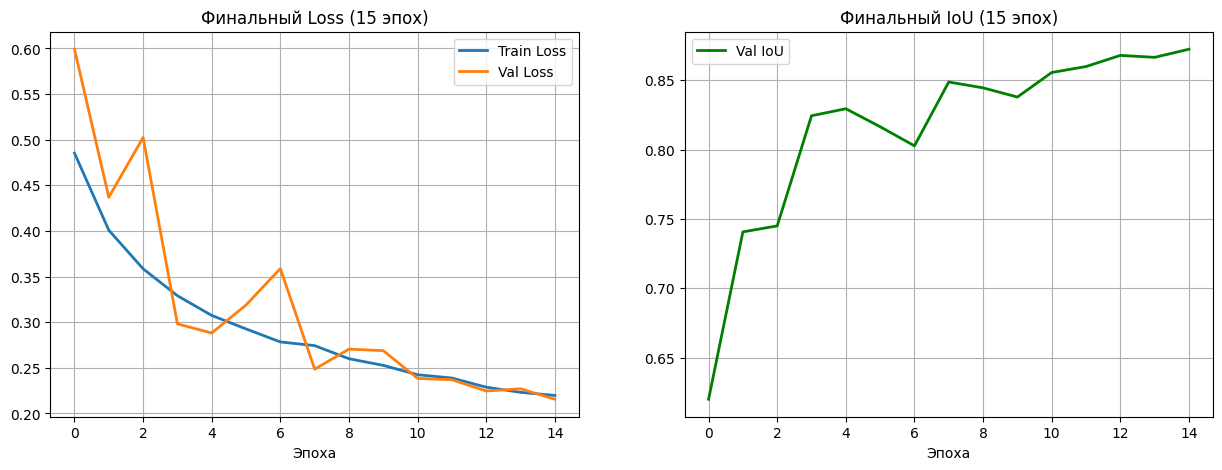


Визуализация результатов на тестовой выборке:


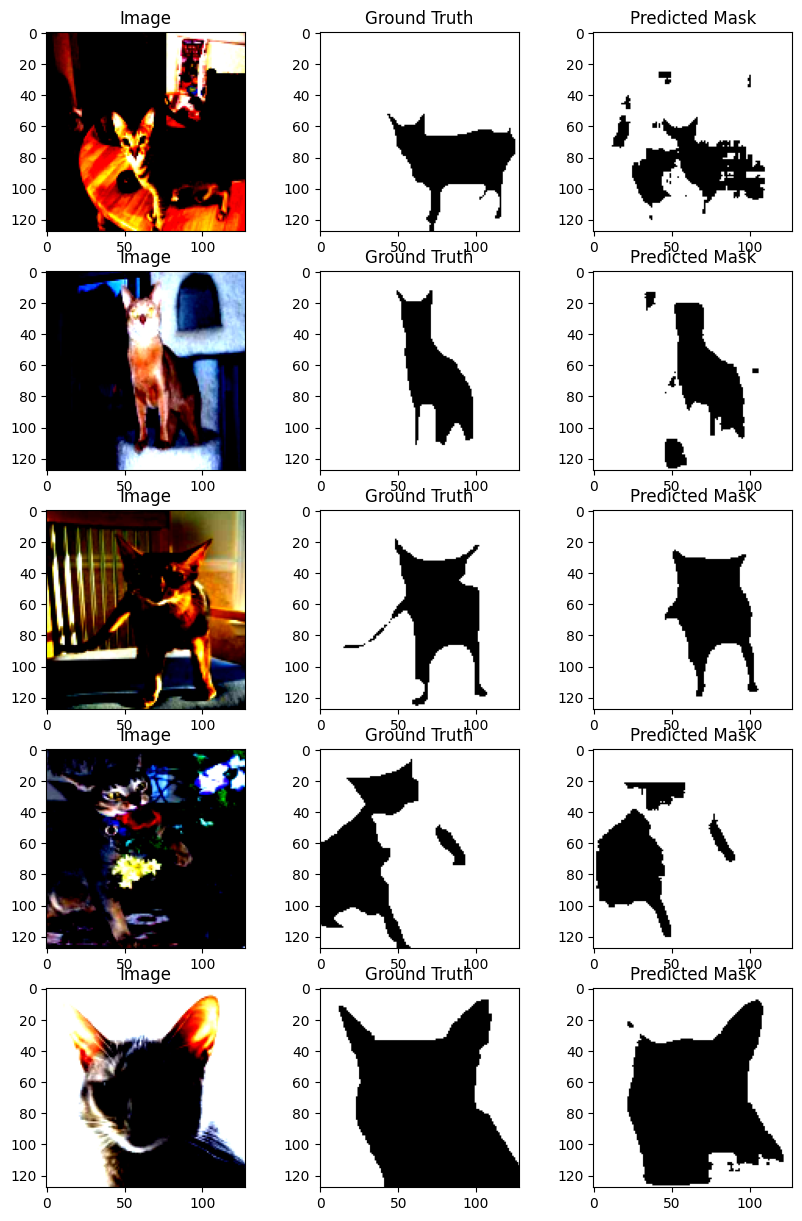

In [13]:
config.learning_rate = 0.001
config.batch_size = 16
config.epochs = 15

print(f"\nЗапуск финальной модели (LR={config.learning_rate}, BS={config.batch_size})...")
final_trainer = Trainer(config)
final_trainer.run()

plt.figure(figsize=(15, 5))

#График Loss
plt.subplot(1, 2, 1)
plt.plot(final_trainer.history['train_loss'], label='Train Loss', lw=2)
plt.plot(final_trainer.history['val_loss'], label='Val Loss', lw=2)
plt.title('Финальный Loss (15 эпох)')
plt.xlabel('Эпоха'); plt.legend(); plt.grid(True)

#График IoU
plt.subplot(1, 2, 2)
plt.plot(final_trainer.history['val_iou'], label='Val IoU', color='green', lw=2)
plt.title('Финальный IoU (15 эпох)')
plt.xlabel('Эпоха'); plt.legend(); plt.grid(True)

plt.show()

print("\nВизуализация результатов на тестовой выборке:")
final_trainer.inference_and_plot_samples(n_samples=5)

В  U-Net были добавлены BatchNorm2d для ускорения обучения и более высокого Learning rate.Ещё добавлен Dropout(0.1), чтобы не было резкого переобучения.

Увеличение Batch Size до 32 делает графики Loss более стабильными, так как градиент усредняется по большему количеству примеров.

при Batch Size = 16 модель показала чуть лучшую обобщающую способность благодаря шумам.

Было проведено 3 эксперимента с разными скоростями обучения 10^−3, 5*10^−4, 10^−4, самый плавный и стабильный график и IoU, и Loss у 10^−4, лучшие значения тоже у 10^−4.

Кривая Val Loss местами идет близко к Train Loss и не начинает резко расти вверх к последней эпохе, значит Dropout(0.1) хорошо сработал.

Модель неплохая, на тестовых изображениях точно повторяет контуры животных, что подтверждается ростом Mean IoU и F1-score на валидации.